# Predictive Dependency Drift

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.


In [1]:

from pathlib import Path
import gc
import math
import time
import warnings

import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free_b, total_b = torch.cuda.mem_get_info()
    print(
        f"CUDA free: {free_b/1024**3:.2f} GiB / "
        f"{total_b/1024**3:.2f} GiB"
    )


PyTorch: 2.4.1+cu121
CUDA: True
GPU: NVIDIA A100-SXM4-80GB
CUDA free: 76.13 GiB / 79.15 GiB


## 1. Configuration

In [2]:

DATASETS = {
    "Electricity": Path(
        "/data/dataset/electricity/electricity.csv"
    ),
    "Weather": Path(
        "/data/dataset/weather/weather.csv"
    ),
    "Solar": Path(
        "/data/dataset/solar/solar_AL.txt"
    ),
    "ETTh1": Path(
        "/data/dataset/ETT-small/ETTh1.csv"
    ),
    "ETTm1": Path(
        "/data/dataset/ETT-small/ETTm1.csv"
    ),
}

PRED_LENS = [96, 720]

BASE_HISTORY = 24

SOURCE_FEATURE_NAMES = [
    "last",
    "mean3",
    "mean12",
    "delta12",
]

SOURCE_DIM = len(
    SOURCE_FEATURE_NAMES
)

FIT_RATIO_WITHIN_TRAIN = 0.70

MAX_FIT_ORIGINS = 6000
MAX_SCORE_ORIGINS = 3000

RIDGE_BASE = 1e-2
RIDGE_SOURCE_RESIDUAL = 1e-2
RIDGE_SOURCE_GAIN = 1e-2

MIN_TOP_K = 2
MAX_TOP_K = 20
TOP_FRAC = 0.10

WEEK_DAYS = 7

BOOTSTRAP_REPEATS = 1000
BOOTSTRAP_SEED = 2027

OUTPUT_DIR = Path(
    "./results_predictive_dependency_drift"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ADAPTER_RESULT_CANDIDATES = [
    Path(
        "./results_crossdomain_horizon_adapter_screening/"
        "crossdomain_screening_results.csv"
    ),
    Path(
        "./results_crossdomain_horizon_adapter_screening/"
        "results_partial.csv"
    ),
]

CORR_DRIFT_CANDIDATES = [
    Path(
        "./results_crossdomain_horizon_dependency_drift/"
        "endpoint_dependency_drift.csv"
    ),
]

print("DEVICE:", DEVICE)
print("OUTPUT_DIR:", OUTPUT_DIR)


DEVICE: cuda
OUTPUT_DIR: results_predictive_dependency_drift


In [3]:

DATASET_META = {
    "Electricity": {
        "fallback_samples_per_day": 24,
    },
    "Weather": {
        "fallback_samples_per_day": 144,
    },
    "Solar": {
        "fallback_samples_per_day": 144,
    },
    "ETTh1": {
        "fallback_samples_per_day": 24,
    },
    "ETTm1": {
        "fallback_samples_per_day": 96,
    },
}


def anchors_for_pred_len(H):

    return sorted(
        set([
            1,
            max(
                1,
                int(
                    round(
                        0.25 * H
                    )
                )
            ),
            max(
                1,
                int(
                    round(
                        0.50 * H
                    )
                )
            ),
            H,
        ])
    )


ALL_HORIZONS = sorted(
    set(
        h
        for H in PRED_LENS
        for h in anchors_for_pred_len(H)
    )
)

print("Unique horizons:", ALL_HORIZONS)

for H in PRED_LENS:
    print(
        f"H={H}:",
        anchors_for_pred_len(H)
    )


Unique horizons: [1, 24, 48, 96, 180, 360, 720]
H=96: [1, 24, 48, 96]
H=720: [1, 180, 360, 720]


## 2. Dataset loading

In [4]:

def infer_samples_per_day(
    date_series,
    fallback
):
    if date_series is None:
        return int(
            fallback
        )

    dt = pd.to_datetime(
        date_series,
        errors="coerce"
    ).dropna()

    if len(dt) < 3:
        return int(
            fallback
        )

    delta = (
        dt.sort_values()
        .diff()
        .dropna()
        .dt.total_seconds()
    )

    delta = delta[
        delta > 0
    ]

    if len(delta) == 0:
        return int(
            fallback
        )

    sec = float(
        delta.median()
    )

    if sec <= 0:
        return int(
            fallback
        )

    return max(
        1,
        int(
            round(
                86400.0 / sec
            )
        )
    )


def standard_train_end(
    dataset_name,
    T
):
    if dataset_name == "ETTh1":

        return min(
            12 * 30 * 24,
            T
        )

    if dataset_name == "ETTm1":

        return min(
            12 * 30 * 24 * 4,
            T
        )

    return int(
        0.70 * T
    )


In [5]:

def load_dataset(
    dataset_name
):
    path = DATASETS[
        dataset_name
    ]

    if not path.exists():
        raise FileNotFoundError(
            path
        )

    date_series = None

    if path.suffix.lower() == ".csv":

        df = pd.read_csv(
            path
        )

        date_col = None

        for candidate in [
            "date",
            "datetime",
            "timestamp",
            "time",
        ]:

            if candidate in df.columns:
                date_col = candidate
                break

        if date_col is None:

            first_col = (
                df.columns[0]
            )

            if not pd.api.types.is_numeric_dtype(
                df[first_col]
            ):
                date_col = first_col

        if date_col is not None:

            date_series = (
                df[
                    date_col
                ].copy()
            )

            feature_df = (
                df.drop(
                    columns=[
                        date_col
                    ]
                )
            )

        else:

            feature_df = df

        feature_df = (
            feature_df
            .select_dtypes(
                include=[
                    np.number
                ]
            )
        )

        x = (
            feature_df
            .to_numpy(
                dtype=np.float32
            )
        )

    else:

        try:

            x = np.loadtxt(
                path,
                delimiter=",",
                dtype=np.float32
            )

        except Exception:

            x = np.loadtxt(
                path,
                dtype=np.float32
            )

        if x.ndim == 1:
            x = x[:, None]

    if x.ndim != 2:

        raise ValueError(
            f"{dataset_name}: "
            f"unexpected shape {x.shape}"
        )

    if not np.isfinite(
        x
    ).all():

        raise ValueError(
            f"{dataset_name}: "
            "non-finite values found"
        )

    T, C = x.shape

    train_end = (
        standard_train_end(
            dataset_name,
            T
        )
    )

    mean = x[
        :train_end
    ].mean(
        axis=0,
        keepdims=True
    )

    std = x[
        :train_end
    ].std(
        axis=0,
        keepdims=True
    )

    std = np.maximum(
        std,
        1e-6
    )

    x = (
        x - mean
    ) / std

    samples_per_day = (
        infer_samples_per_day(
            date_series,
            DATASET_META[
                dataset_name
            ][
                "fallback_samples_per_day"
            ]
        )
    )

    meta = {
        "dataset":
            dataset_name,
        "path":
            str(path),
        "T":
            T,
        "C":
            C,
        "train_end":
            train_end,
        "samples_per_day":
            samples_per_day,
    }

    return x, meta


## 3. Diagnostic train/score origin split

In [6]:

def evenly_subsample(
    arr,
    max_n
):
    if len(arr) <= max_n:
        return arr

    idx = np.linspace(
        0,
        len(arr) - 1,
        num=max_n,
        dtype=np.int64
    )

    return arr[
        idx
    ]


def make_diagnostic_origins(
    train_end
):
    # Same origin pool for every horizon,
    # so horizon-to-horizon drift is not caused
    # by different sample sets.
    max_h = max(
        ALL_HORIZONS
    )

    first_origin = (
        BASE_HISTORY
    )

    last_origin = (
        train_end
        - max_h
    )

    if last_origin <= first_origin:

        raise ValueError(
            "Training segment is too short."
        )

    origins = np.arange(
        first_origin,
        last_origin + 1,
        dtype=np.int64
    )

    split = int(
        len(origins)
        * FIT_RATIO_WITHIN_TRAIN
    )

    fit_origins = origins[
        :split
    ]

    score_origins = origins[
        split:
    ]

    fit_origins = (
        evenly_subsample(
            fit_origins,
            MAX_FIT_ORIGINS
        )
    )

    score_origins = (
        evenly_subsample(
            score_origins,
            MAX_SCORE_ORIGINS
        )
    )

    return (
        fit_origins,
        score_origins
    )


## 4. Build target-history and source summary features

In [7]:

def lag_matrix_for_channel(
    x,
    origins,
    channel,
    history=BASE_HISTORY
):
    offsets = np.arange(
        history,
        0,
        -1,
        dtype=np.int64
    )

    idx = (
        origins[:, None]
        - offsets[
            None,
            :
        ]
    )

    return x[
        idx,
        channel
    ].astype(
        np.float32
    )


def build_source_features(
    x,
    origins
):
    # [N, C, 4]
    last = x[
        origins - 1
    ]

    mean3 = (
        x[
            origins - 1
        ]
        +
        x[
            origins - 2
        ]
        +
        x[
            origins - 3
        ]
    ) / 3.0

    # mean over t-12 ... t-1
    mean12 = np.zeros_like(
        last,
        dtype=np.float32
    )

    for lag in range(
        1,
        13
    ):

        mean12 += x[
            origins - lag
        ]

    mean12 /= 12.0

    delta12 = (
        x[
            origins - 1
        ]
        -
        x[
            origins - 12
        ]
    )

    z = np.stack(
        [
            last,
            mean3,
            mean12,
            delta12,
        ],
        axis=-1
    )

    return z.astype(
        np.float32
    )


## 5. Ridge helpers

In [8]:

def add_intercept(
    X
):
    ones = torch.ones(
        X.shape[0],
        1,
        device=X.device,
        dtype=X.dtype
    )

    return torch.cat(
        [
            ones,
            X
        ],
        dim=1
    )


def ridge_solve(
    X,
    Y,
    lam
):
    """
    Sample-normalized ridge:
        (X'X/N + lam I)^-1 X'Y/N

    Intercept is assumed to already be included
    in X; its penalty is set to zero.
    """
    N = X.shape[0]

    gram = (
        X.transpose(
            0,
            1
        )
        @ X
    ) / float(N)

    rhs = (
        X.transpose(
            0,
            1
        )
        @ Y
    ) / float(N)

    reg = torch.eye(
        gram.shape[0],
        device=X.device,
        dtype=X.dtype
    ) * float(
        lam
    )

    reg[
        0,
        0
    ] = 0.0

    return torch.linalg.solve(
        gram + reg,
        rhs
    )


## 6. Batched group ridge for source features

In [9]:

def source_group_gram(
    RZ_fit,
    lam
):
    """
    RZ_fit: [N, C, F]

    Returns:
        G: [C, F, F]
    """
    N = RZ_fit.shape[0]

    G = torch.einsum(
        "ncf,ncg->cfg",
        RZ_fit,
        RZ_fit
    ) / float(N)

    eye = torch.eye(
        RZ_fit.shape[-1],
        device=RZ_fit.device,
        dtype=RZ_fit.dtype
    ).unsqueeze(
        0
    )

    return (
        G
        +
        float(lam)
        * eye
    )


def source_group_coefficients(
    G,
    RZ_fit,
    y_residual
):
    N = RZ_fit.shape[0]

    rhs = torch.einsum(
        "ncf,n->cf",
        RZ_fit,
        y_residual
    ) / float(N)

    gamma = torch.linalg.solve(
        G,
        rhs.unsqueeze(
            -1
        )
    ).squeeze(
        -1
    )

    return gamma


## 7. Metric helpers

In [10]:

def sparse_k(
    C
):
    possible = max(
        1,
        C - 1
    )

    K = int(
        math.ceil(
            TOP_FRAC
            * possible
        )
    )

    K = max(
        MIN_TOP_K,
        K
    )

    K = min(
        MAX_TOP_K,
        K,
        possible
    )

    return K


def topk_idx_numpy(
    score_matrix,
    K
):
    # score_matrix: [target, source]
    return np.argpartition(
        -score_matrix,
        kth=K-1,
        axis=1
    )[
        :,
        :K
    ]


def jaccard_per_target_numpy(
    idx_a,
    idx_b
):
    C, K = idx_a.shape

    out = np.zeros(
        C,
        dtype=np.float64
    )

    for i in range(
        C
    ):

        a = set(
            idx_a[
                i
            ].tolist()
        )

        b = set(
            idx_b[
                i
            ].tolist()
        )

        out[
            i
        ] = (
            len(
                a & b
            )
            /
            max(
                1,
                len(
                    a | b
                )
            )
        )

    return out


def bootstrap_mean_ci(
    values,
    repeats=
        BOOTSTRAP_REPEATS,
    seed=
        BOOTSTRAP_SEED
):
    values = np.asarray(
        values,
        dtype=np.float64
    )

    rng = (
        np.random
        .default_rng(
            seed
        )
    )

    n = len(
        values
    )

    means = np.empty(
        repeats,
        dtype=np.float64
    )

    for b in range(
        repeats
    ):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        means[
            b
        ] = values[
            idx
        ].mean()

    return (
        float(
            values.mean()
        ),
        float(
            np.quantile(
                means,
                0.025
            )
        ),
        float(
            np.quantile(
                means,
                0.975
            )
        )
    )


## 8. Synthetic pre-flight

In [11]:

# Test core tensor operations before long run.

torch.manual_seed(
    2026
)

Nf = 100
Ns = 80
C = 8
F = SOURCE_DIM
D = BASE_HISTORY + 1

Xf = torch.randn(
    Nf,
    D,
    device=DEVICE
)

Xs = torch.randn(
    Ns,
    D,
    device=DEVICE
)

Zf = torch.randn(
    Nf,
    C,
    F,
    device=DEVICE
)

Zs = torch.randn(
    Ns,
    C,
    F,
    device=DEVICE
)

beta_z = ridge_solve(
    Xf,
    Zf.reshape(
        Nf,
        C * F
    ),
    RIDGE_SOURCE_RESIDUAL
)

RZf = (
    Zf.reshape(
        Nf,
        C * F
    )
    -
    Xf @ beta_z
).reshape(
    Nf,
    C,
    F
)

RZs = (
    Zs.reshape(
        Ns,
        C * F
    )
    -
    Xs @ beta_z
).reshape(
    Ns,
    C,
    F
)

G = source_group_gram(
    RZf,
    RIDGE_SOURCE_GAIN
)

ry = torch.randn(
    Nf,
    device=DEVICE
)

gamma = (
    source_group_coefficients(
        G,
        RZf,
        ry
    )
)

assert gamma.shape == (
    C,
    F
)

assert torch.isfinite(
    gamma
).all()

print(
    "Predictive-dependency pre-flight: OK"
)

del (
    Xf,
    Xs,
    Zf,
    Zs,
    beta_z,
    RZf,
    RZs,
    G,
    ry,
    gamma
)

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


Predictive-dependency pre-flight: OK


# 9. Main predictive-dependency computation

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.


In [12]:

dataset_rows = []
horizon_rows = []
pair_rows = []
endpoint_rows = []

predictive_score_store = {}

for dataset_name in (
    DATASETS.keys()
):

    print(
        "\n"
        + "#"
        * 110
    )

    print(
        dataset_name
    )

    print(
        "#"
        * 110
    )

    t_dataset = time.time()

    x, meta = load_dataset(
        dataset_name
    )

    T, C = x.shape

    K = sparse_k(
        C
    )

    (
        fit_origins,
        score_origins
    ) = make_diagnostic_origins(
        meta[
            "train_end"
        ]
    )

    print(
        "shape:",
        x.shape
    )

    print(
        "train_end:",
        meta[
            "train_end"
        ]
    )

    print(
        "fit origins:",
        len(
            fit_origins
        )
    )

    print(
        "score origins:",
        len(
            score_origins
        )
    )

    print(
        "K:",
        K
    )

    # Alternating weekly blocks within score segment.
    block_len = (
        meta[
            "samples_per_day"
        ]
        * WEEK_DAYS
    )

    block_id = (
        score_origins
        // int(
            block_len
        )
    )

    score_mask_A_np = (
        block_id % 2
        == 0
    )

    score_mask_B_np = ~(
        score_mask_A_np
    )

    if (
        score_mask_A_np.sum()
        < 20
        or
        score_mask_B_np.sum()
        < 20
    ):

        # Fallback to alternating samples if
        # the dataset/segment is too short.
        score_mask_A_np = (
            np.arange(
                len(
                    score_origins
                )
            )
            % 2
            == 0
        )

        score_mask_B_np = ~(
            score_mask_A_np
        )

    score_mask_A = torch.as_tensor(
        score_mask_A_np,
        device=DEVICE,
        dtype=torch.bool
    )

    score_mask_B = torch.as_tensor(
        score_mask_B_np,
        device=DEVICE,
        dtype=torch.bool
    )

    # Global source summaries are independent
    # of the target channel.
    Z_fit_np = build_source_features(
        x,
        fit_origins
    )

    Z_score_np = build_source_features(
        x,
        score_origins
    )

    Z_fit = torch.as_tensor(
        Z_fit_np,
        device=DEVICE,
        dtype=torch.float32
    )

    Z_score = torch.as_tensor(
        Z_score_np,
        device=DEVICE,
        dtype=torch.float32
    )

    Nf = len(
        fit_origins
    )

    Ns = len(
        score_origins
    )

    # Predictive score matrices:
    # [target, source]
    P_full = {
        h:
            np.full(
                (
                    C,
                    C
                ),
                -np.inf,
                dtype=np.float32
            )
        for h in ALL_HORIZONS
    }

    P_A = {
        h:
            np.full(
                (
                    C,
                    C
                ),
                -np.inf,
                dtype=np.float32
            )
        for h in ALL_HORIZONS
    }

    P_B = {
        h:
            np.full(
                (
                    C,
                    C
                ),
                -np.inf,
                dtype=np.float32
            )
        for h in ALL_HORIZONS
    }

    base_mse_by_h = {
        h:
            []
        for h in ALL_HORIZONS
    }

    best_source_gain_by_h = {
        h:
            []
        for h in ALL_HORIZONS
    }

    topk_gain_by_h = {
        h:
            []
        for h in ALL_HORIZONS
    }

    positive_source_fraction_by_h = {
        h:
            []
        for h in ALL_HORIZONS
    }

    # -----------------------------------------
    # Target loop
    # -----------------------------------------
    for target in range(
        C
    ):

        if (
            target % 25
            == 0
            or
            target == C - 1
        ):

            print(
                f"  target "
                f"{target+1}/{C}"
            )

        X_fit_np = (
            lag_matrix_for_channel(
                x,
                fit_origins,
                target,
                history=
                    BASE_HISTORY
            )
        )

        X_score_np = (
            lag_matrix_for_channel(
                x,
                score_origins,
                target,
                history=
                    BASE_HISTORY
            )
        )

        X_fit = add_intercept(
            torch.as_tensor(
                X_fit_np,
                device=DEVICE,
                dtype=torch.float32
            )
        )

        X_score = add_intercept(
            torch.as_tensor(
                X_score_np,
                device=DEVICE,
                dtype=torch.float32
            )
        )

        # -------------------------------------
        # Residualize all source summary
        # features against target own history.
        # This is horizon-independent.
        # -------------------------------------
        beta_z = ridge_solve(
            X_fit,
            Z_fit.reshape(
                Nf,
                C * SOURCE_DIM
            ),
            RIDGE_SOURCE_RESIDUAL
        )

        RZ_fit = (
            Z_fit.reshape(
                Nf,
                C * SOURCE_DIM
            )
            -
            X_fit @ beta_z
        ).reshape(
            Nf,
            C,
            SOURCE_DIM
        )

        RZ_score = (
            Z_score.reshape(
                Ns,
                C * SOURCE_DIM
            )
            -
            X_score @ beta_z
        ).reshape(
            Ns,
            C,
            SOURCE_DIM
        )

        G = source_group_gram(
            RZ_fit,
            RIDGE_SOURCE_GAIN
        )

        # -------------------------------------
        # Horizon loop
        # -------------------------------------
        for h in ALL_HORIZONS:

            y_fit = torch.as_tensor(
                x[
                    fit_origins
                    + h
                    - 1,
                    target
                ],
                device=DEVICE,
                dtype=torch.float32
            )

            y_score = torch.as_tensor(
                x[
                    score_origins
                    + h
                    - 1,
                    target
                ],
                device=DEVICE,
                dtype=torch.float32
            )

            beta_y = ridge_solve(
                X_fit,
                y_fit,
                RIDGE_BASE
            )

            r_fit = (
                y_fit
                -
                X_fit
                @ beta_y
            )

            r_score = (
                y_score
                -
                X_score
                @ beta_y
            )

            gamma = (
                source_group_coefficients(
                    G,
                    RZ_fit,
                    r_fit
                )
            )

            source_correction = (
                torch.einsum(
                    "ncf,cf->nc",
                    RZ_score,
                    gamma
                )
            )

            aug_error = (
                r_score[
                    :,
                    None
                ]
                -
                source_correction
            )

            base_mse = (
                r_score.square()
                .mean()
            )

            aug_mse = (
                aug_error.square()
                .mean(
                    dim=0
                )
            )

            gain_full = (
                100.0
                * (
                    base_mse
                    - aug_mse
                )
                /
                base_mse.clamp_min(
                    1e-12
                )
            )

            # A/B score split.
            rA = r_score[
                score_mask_A
            ]

            rB = r_score[
                score_mask_B
            ]

            eA = aug_error[
                score_mask_A
            ]

            eB = aug_error[
                score_mask_B
            ]

            base_A = (
                rA.square()
                .mean()
            )

            base_B = (
                rB.square()
                .mean()
            )

            aug_A = (
                eA.square()
                .mean(
                    dim=0
                )
            )

            aug_B = (
                eB.square()
                .mean(
                    dim=0
                )
            )

            gain_A = (
                100.0
                * (
                    base_A
                    - aug_A
                )
                /
                base_A.clamp_min(
                    1e-12
                )
            )

            gain_B = (
                100.0
                * (
                    base_B
                    - aug_B
                )
                /
                base_B.clamp_min(
                    1e-12
                )
            )

            # Self source excluded.
            gain_full[
                target
            ] = float(
                "-inf"
            )

            gain_A[
                target
            ] = float(
                "-inf"
            )

            gain_B[
                target
            ] = float(
                "-inf"
            )

            P_full[
                h
            ][
                target
            ] = (
                gain_full
                .detach()
                .cpu()
                .numpy()
            )

            P_A[
                h
            ][
                target
            ] = (
                gain_A
                .detach()
                .cpu()
                .numpy()
            )

            P_B[
                h
            ][
                target
            ] = (
                gain_B
                .detach()
                .cpu()
                .numpy()
            )

            finite_gain = (
                gain_full[
                    torch.arange(
                        C,
                        device=DEVICE
                    )
                    != target
                ]
            )

            base_mse_by_h[
                h
            ].append(
                float(
                    base_mse.item()
                )
            )

            best_source_gain_by_h[
                h
            ].append(
                float(
                    finite_gain
                    .max()
                    .item()
                )
            )

            top_vals = torch.topk(
                finite_gain,
                k=min(
                    K,
                    len(
                        finite_gain
                    )
                )
            ).values

            topk_gain_by_h[
                h
            ].append(
                float(
                    top_vals
                    .mean()
                    .item()
                )
            )

            positive_source_fraction_by_h[
                h
            ].append(
                float(
                    (
                        finite_gain
                        > 0
                    )
                    .float()
                    .mean()
                    .item()
                )
            )

        del (
            X_fit,
            X_score,
            beta_z,
            RZ_fit,
            RZ_score,
            G
        )

        if (
            target % 25
            == 0
            and
            DEVICE.type
            == "cuda"
        ):

            torch.cuda.empty_cache()

    # -----------------------------------------
    # Horizon-wise stability
    # -----------------------------------------
    stability = {}

    for h in ALL_HORIZONS:

        idx_A = topk_idx_numpy(
            P_A[
                h
            ],
            K
        )

        idx_B = topk_idx_numpy(
            P_B[
                h
            ],
            K
        )

        same_jac = (
            jaccard_per_target_numpy(
                idx_A,
                idx_B
            )
        )

        stability[
            h
        ] = same_jac

        horizon_rows.append({
            "dataset":
                dataset_name,
            "horizon":
                h,
            "channels":
                C,
            "top_k":
                K,
            "same_horizon_jaccard_mean":
                float(
                    same_jac.mean()
                ),
            "same_horizon_jaccard_median":
                float(
                    np.median(
                        same_jac
                    )
                ),
            "mean_self_history_base_mse":
                float(
                    np.mean(
                        base_mse_by_h[
                            h
                        ]
                    )
                ),
            "mean_best_source_gain_%":
                float(
                    np.mean(
                        best_source_gain_by_h[
                            h
                        ]
                    )
                ),
            "mean_topk_source_gain_%":
                float(
                    np.mean(
                        topk_gain_by_h[
                            h
                        ]
                    )
                ),
            "mean_positive_source_fraction":
                float(
                    np.mean(
                        positive_source_fraction_by_h[
                            h
                        ]
                    )
                ),
        })

    # -----------------------------------------
    # Cross-horizon predictive drift
    # -----------------------------------------
    for H in PRED_LENS:

        anchors = (
            anchors_for_pred_len(
                H
            )
        )

        local_rows = []

        for a in range(
            len(
                anchors
            )
        ):

            for b in range(
                a + 1,
                len(
                    anchors
                )
            ):

                h1 = anchors[
                    a
                ]

                h2 = anchors[
                    b
                ]

                idx1 = topk_idx_numpy(
                    P_full[
                        h1
                    ],
                    K
                )

                idx2 = topk_idx_numpy(
                    P_full[
                        h2
                    ],
                    K
                )

                cross_jac = (
                    jaccard_per_target_numpy(
                        idx1,
                        idx2
                    )
                )

                cross_drift = (
                    1.0
                    - cross_jac
                )

                noise = (
                    (
                        1.0
                        - stability[
                            h1
                        ]
                    )
                    +
                    (
                        1.0
                        - stability[
                            h2
                        ]
                    )
                ) / 2.0

                adjusted = (
                    cross_drift
                    - noise
                )

                row = {
                    "dataset":
                        dataset_name,
                    "pred_len":
                        H,
                    "h1":
                        h1,
                    "h2":
                        h2,
                    "relative_gap":
                        (
                            h2 - h1
                        )
                        / float(H),
                    "top_k":
                        K,
                    "predictive_jaccard":
                        float(
                            cross_jac.mean()
                        ),
                    "predictive_drift":
                        float(
                            cross_drift.mean()
                        ),
                    "predictive_noise":
                        float(
                            noise.mean()
                        ),
                    "predictive_adjusted_drift":
                        float(
                            adjusted.mean()
                        ),
                    "positive_adjusted_target_fraction":
                        float(
                            (
                                adjusted
                                > 0
                            ).mean()
                        ),
                }

                pair_rows.append(
                    row
                )

                local_rows.append(
                    row
                )

                if (
                    h1 == 1
                    and
                    h2 == H
                ):

                    (
                        mean_adj,
                        ci_low,
                        ci_high
                    ) = bootstrap_mean_ci(
                        adjusted,
                        repeats=
                            BOOTSTRAP_REPEATS,
                        seed=
                            BOOTSTRAP_SEED
                            + H
                            + C
                    )

                    endpoint = (
                        row.copy()
                    )

                    endpoint[
                        "predictive_adjusted_ci_low"
                    ] = ci_low

                    endpoint[
                        "predictive_adjusted_ci_high"
                    ] = ci_high

                    endpoint[
                        "mean_best_source_gain_h1_%"
                    ] = float(
                        np.mean(
                            best_source_gain_by_h[
                                1
                            ]
                        )
                    )

                    endpoint[
                        "mean_best_source_gain_hH_%"
                    ] = float(
                        np.mean(
                            best_source_gain_by_h[
                                H
                            ]
                        )
                    )

                    endpoint[
                        "mean_topk_source_gain_h1_%"
                    ] = float(
                        np.mean(
                            topk_gain_by_h[
                                1
                            ]
                        )
                    )

                    endpoint[
                        "mean_topk_source_gain_hH_%"
                    ] = float(
                        np.mean(
                            topk_gain_by_h[
                                H
                            ]
                        )
                    )

                    endpoint[
                        "positive_source_fraction_h1"
                    ] = float(
                        np.mean(
                            positive_source_fraction_by_h[
                                1
                            ]
                        )
                    )

                    endpoint[
                        "positive_source_fraction_hH"
                    ] = float(
                        np.mean(
                            positive_source_fraction_by_h[
                                H
                            ]
                        )
                    )

                    endpoint_rows.append(
                        endpoint
                    )

        local_df = pd.DataFrame(
            local_rows
        )

        dataset_rows.append({
            "dataset":
                dataset_name,
            "pred_len":
                H,
            "channels":
                C,
            "top_k":
                K,
            "avg_pairwise_predictive_adjusted_drift":
                float(
                    local_df[
                        "predictive_adjusted_drift"
                    ].mean()
                ),
        })

    predictive_score_store[
        dataset_name
    ] = {
        h:
            P_full[
                h
            ]
        for h in ALL_HORIZONS
    }

    # Partial save after each dataset.
    pd.DataFrame(
        horizon_rows
    ).to_csv(
        OUTPUT_DIR
        /
        "horizon_predictive_dependency.csv",
        index=False
    )

    pd.DataFrame(
        pair_rows
    ).to_csv(
        OUTPUT_DIR
        /
        "pairwise_predictive_drift.csv",
        index=False
    )

    pd.DataFrame(
        endpoint_rows
    ).to_csv(
        OUTPUT_DIR
        /
        "endpoint_predictive_drift.csv",
        index=False
    )

    print(
        f"{dataset_name} elapsed: "
        f"{time.time()-t_dataset:.1f}s"
    )

    del (
        x,
        Z_fit_np,
        Z_score_np,
        Z_fit,
        Z_score,
        P_full,
        P_A,
        P_B
    )

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()



##############################################################################################################
Electricity
##############################################################################################################
shape: (26304, 321)
train_end: 18412
fit origins: 6000
score origins: 3000
K: 20
  target 1/321
  target 26/321
  target 51/321
  target 76/321
  target 101/321
  target 126/321
  target 151/321
  target 176/321
  target 201/321
  target 226/321
  target 251/321
  target 276/321
  target 301/321
  target 321/321
Electricity elapsed: 6.6s

##############################################################################################################
Weather
##############################################################################################################
shape: (52696, 21)
train_end: 36887
fit origins: 6000
score origins: 3000
K: 2
  target 1/21
  target 21/21
Weather elapsed: 0.4s

###############################################################

## 10. Endpoint predictive drift summary

In [13]:

endpoint_df = pd.DataFrame(
    endpoint_rows
)

display(
    endpoint_df[
        [
            "dataset",
            "pred_len",
            "top_k",
            "predictive_adjusted_drift",
            "predictive_adjusted_ci_low",
            "predictive_adjusted_ci_high",
            "positive_adjusted_target_fraction",
            "mean_best_source_gain_h1_%",
            "mean_best_source_gain_hH_%",
            "mean_topk_source_gain_h1_%",
            "mean_topk_source_gain_hH_%",
            "positive_source_fraction_h1",
            "positive_source_fraction_hH",
        ]
    ].round(
        4
    )
)

endpoint_df.to_csv(
    OUTPUT_DIR
    /
    "endpoint_predictive_drift.csv",
    index=False
)


,dataset,pred_len,top_k,predictive_adjusted_drift,predictive_adjusted_ci_low,predictive_adjusted_ci_high,positive_adjusted_target_fraction,mean_best_source_gain_h1_%,mean_best_source_gain_hH_%,mean_topk_source_gain_h1_%,mean_topk_source_gain_hH_%,positive_source_fraction_h1,positive_source_fraction_hH
0,Electricity,96,20,0.3619,0.3473,0.3768,0.9969,10.0966,10.7696,1.0285,6.5193,0.8313,0.7222
1,Electricity,720,20,0.4832,0.4699,0.4962,1.0000,10.0966,14.9585,1.0285,9.3559,0.8313,0.6547
2,Weather,96,2,0.3492,0.1746,0.5317,0.7143,15.2020,15.0030,13.8231,14.4317,0.6810,0.6905
3,Weather,720,2,0.3095,0.1188,0.4921,0.6667,15.2020,10.5430,13.8231,9.7583,0.6810,0.5833
4,Solar,96,14,0.4329,0.4060,0.4593,0.9562,8.6380,7.4627,6.6290,5.6794,0.9979,0.9871
5,Solar,720,14,0.1514,0.1379,0.1663,0.9708,8.6380,22.3357,6.6290,18.7945,0.9979,0.9888
6,ETTh1,96,2,0.5238,0.2857,0.7619,0.8571,2.1828,2.6478,1.7777,1.5442,0.7143,0.4048
7,ETTh1,720,2,0.1429,-0.1429,0.5238,0.5714,2.1828,4.9339,1.7777,4.3043,0.7143,0.4048
8,ETTm1,96,2,-0.0000,-0.2857,0.2857,0.2857,1.8216,3.2882,1.2290,2.0493,0.7619,0.3333
9,ETTm1,720,2,0.1429,-0.1905,0.4762,0.4286,1.8216,6.1349,1.2290,4.2945,0.7619,0.5476


## 11. Predictive drift matrix

In [14]:

predictive_drift_pivot = (
    endpoint_df
    .pivot(
        index=
            "dataset",
        columns=
            "pred_len",
        values=
            "predictive_adjusted_drift"
    )
)

display(
    predictive_drift_pivot.round(
        4
    )
)


pred_len,96,720
dataset,,
ETTh1,0.5238,0.1429
ETTm1,-0.0000,0.1429
Electricity,0.3619,0.4832
Solar,0.4329,0.1514
Weather,0.3492,0.3095


## 12. Predictive source utility matrix

In [15]:

utility_pivot = (
    endpoint_df
    .pivot(
        index=
            "dataset",
        columns=
            "pred_len",
        values=
            "mean_topk_source_gain_hH_%"
    )
)

print(
    "Mean Top-K marginal source utility "
    "at the endpoint horizon (%)"
)

display(
    utility_pivot.round(
        4
    )
)


Mean Top-K marginal source utility at the endpoint horizon (%)


pred_len,96,720
dataset,,
ETTh1,1.5442,4.3043
ETTm1,2.0493,4.2945
Electricity,6.5193,9.3559
Solar,5.6794,18.7945
Weather,14.4317,9.7583


# 13. Merge with neural Horizon Adapter results

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.


In [16]:

adapter_path = None

for p in (
    ADAPTER_RESULT_CANDIDATES
):

    if p.exists():

        adapter_path = p
        break

if adapter_path is None:

    print(
        "Adapter result CSV not found."
    )

    predictive_gain_df = None

else:

    print(
        "Found adapter results:",
        adapter_path
    )

    adapter_df = pd.read_csv(
        adapter_path
    )

    required = {
        "dataset",
        "pred_len",
        "raw_mse_gain_%",
    }

    missing = (
        required
        - set(
            adapter_df.columns
        )
    )

    if missing:

        raise ValueError(
            f"Missing columns: "
            f"{missing}"
        )

    predictive_gain_df = (
        endpoint_df
        .merge(
            adapter_df[
                [
                    "dataset",
                    "pred_len",
                    "raw_mse_gain_%",
                    "gated_mse_gain_%",
                    "selected_mode",
                ]
            ],
            on=[
                "dataset",
                "pred_len"
            ],
            how="inner"
        )
    )

    display(
        predictive_gain_df[
            [
                "dataset",
                "pred_len",
                "predictive_adjusted_drift",
                "mean_topk_source_gain_hH_%",
                "raw_mse_gain_%",
                "selected_mode",
            ]
        ].round(
            4
        )
    )

    predictive_gain_df.to_csv(
        OUTPUT_DIR
        /
        "predictive_drift_vs_adapter_gain.csv",
        index=False
    )


Found adapter results: results_crossdomain_horizon_adapter_screening/crossdomain_screening_results.csv


,dataset,pred_len,predictive_adjusted_drift,mean_topk_source_gain_hH_%,raw_mse_gain_%,selected_mode
0,Electricity,96,0.3619,6.5193,0.6113,adapter
1,Electricity,720,0.4832,9.3559,3.1111,adapter
2,Weather,96,0.3492,14.4317,0.1568,adapter
3,Weather,720,0.3095,9.7583,0.0839,shared_identity
4,Solar,96,0.4329,5.6794,-0.4835,adapter
5,Solar,720,0.1514,18.7945,-0.1691,adapter
6,ETTh1,96,0.5238,1.5442,0.0571,adapter
7,ETTh1,720,0.1429,4.3043,-0.7865,adapter
8,ETTm1,96,-0.0000,2.0493,0.2122,shared_identity
9,ETTm1,720,0.1429,4.2945,0.1966,adapter


# 14. Compare correlation drift vs predictive drift

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.


In [17]:

corr_path = None

for p in (
    CORR_DRIFT_CANDIDATES
):

    if p.exists():

        corr_path = p
        break

if (
    predictive_gain_df
    is not None
    and
    corr_path
    is not None
):

    print(
        "Found correlation drift:",
        corr_path
    )

    corr_df = pd.read_csv(
        corr_path
    )

    comparison_df = (
        predictive_gain_df
        .merge(
            corr_df[
                [
                    "dataset",
                    "pred_len",
                    "K10pct_adjusted_drift",
                    "adjusted_rank_drift",
                ]
            ],
            on=[
                "dataset",
                "pred_len"
            ],
            how="inner"
        )
    )

    display(
        comparison_df[
            [
                "dataset",
                "pred_len",
                "K10pct_adjusted_drift",
                "predictive_adjusted_drift",
                "mean_topk_source_gain_hH_%",
                "raw_mse_gain_%",
            ]
        ].round(
            4
        )
    )

else:

    comparison_df = None

    if corr_path is None:

        print(
            "Correlation drift CSV not found."
        )


Found correlation drift: results_crossdomain_horizon_dependency_drift/endpoint_dependency_drift.csv


,dataset,pred_len,K10pct_adjusted_drift,predictive_adjusted_drift,mean_topk_source_gain_hH_%,raw_mse_gain_%
0,Electricity,96,0.4688,0.3619,6.5193,0.6113
1,Electricity,720,0.4978,0.4832,9.3559,3.1111
2,Weather,96,0.4603,0.3492,14.4317,0.1568
3,Weather,720,0.0794,0.3095,9.7583,0.0839
4,Solar,96,0.6401,0.4329,5.6794,-0.4835
5,Solar,720,0.4143,0.1514,18.7945,-0.1691
6,ETTh1,96,0.1905,0.5238,1.5442,0.0571
7,ETTh1,720,0.2857,0.1429,4.3043,-0.7865
8,ETTm1,96,0.1905,-0.0000,2.0493,0.2122
9,ETTm1,720,0.2857,0.1429,4.2945,0.1966


## 15. Correlation analysis

In [18]:

def spearman_rank_corr(
    x,
    y
):
    return (
        pd.Series(
            x
        )
        .rank()
        .corr(
            pd.Series(
                y
            )
            .rank()
        )
    )


if comparison_df is not None:

    metrics = [
        "K10pct_adjusted_drift",
        "predictive_adjusted_drift",
        "mean_topk_source_gain_hH_%",
        "mean_best_source_gain_hH_%",
        "positive_source_fraction_hH",
    ]

    rows = []

    for metric in metrics:

        x = comparison_df[
            metric
        ]

        y = comparison_df[
            "raw_mse_gain_%"
        ]

        rows.append({
            "metric":
                metric,
            "pearson_vs_raw_adapter_gain":
                x.corr(
                    y,
                    method=
                        "pearson"
                ),
            "spearman_vs_raw_adapter_gain":
                spearman_rank_corr(
                    x,
                    y
                ),
        })

    correlation_df = pd.DataFrame(
        rows
    )

    display(
        correlation_df.round(
            4
        )
    )

    correlation_df.to_csv(
        OUTPUT_DIR
        /
        "predictive_vs_correlation_drift_correlations.csv",
        index=False
    )


,metric,pearson_vs_raw_adapter_gain,spearman_vs_raw_adapter_gain
0,K10pct_adjusted_drift,0.2220,0.0912
1,predictive_adjusted_drift,0.3936,0.1273
2,mean_topk_source_gain_hH_%,0.1003,0.0061
3,mean_best_source_gain_hH_%,0.2996,0.1879
4,positive_source_fraction_hH,-0.0067,-0.0667


## 16. Key scatter plot

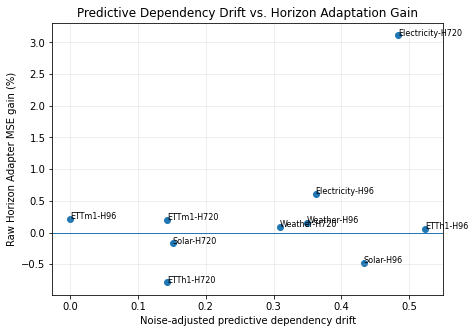

In [19]:

if comparison_df is not None:

    plt.figure(
        figsize=(7, 5)
    )

    plt.scatter(
        comparison_df[
            "predictive_adjusted_drift"
        ],
        comparison_df[
            "raw_mse_gain_%"
        ]
    )

    for _, row in (
        comparison_df.iterrows()
    ):

        plt.annotate(
            f"{row['dataset']}-H{int(row['pred_len'])}",
            (
                row[
                    "predictive_adjusted_drift"
                ],
                row[
                    "raw_mse_gain_%"
                ]
            ),
            fontsize=8
        )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "Noise-adjusted predictive dependency drift"
    )

    plt.ylabel(
        "Raw Horizon Adapter MSE gain (%)"
    )

    plt.title(
        "Predictive Dependency Drift vs. "
        "Horizon Adaptation Gain"
    )

    plt.grid(
        alpha=0.25
    )

    plt.show()


# 17. Solar vs Electricity diagnostic

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.


In [20]:

if comparison_df is not None:

    solar_elec = (
        comparison_df[
            comparison_df[
                "dataset"
            ].isin(
                [
                    "Solar",
                    "Electricity",
                ]
            )
        ]
        [
            [
                "dataset",
                "pred_len",
                "K10pct_adjusted_drift",
                "predictive_adjusted_drift",
                "mean_topk_source_gain_hH_%",
                "positive_source_fraction_hH",
                "raw_mse_gain_%",
            ]
        ]
        .sort_values(
            [
                "dataset",
                "pred_len"
            ]
        )
    )

    display(
        solar_elec.round(
            4
        )
    )


,dataset,pred_len,K10pct_adjusted_drift,predictive_adjusted_drift,mean_topk_source_gain_hH_%,positive_source_fraction_hH,raw_mse_gain_%
0,Electricity,96,0.4688,0.3619,6.5193,0.7222,0.6113
1,Electricity,720,0.4978,0.4832,9.3559,0.6547,3.1111
4,Solar,96,0.6401,0.4329,5.6794,0.9871,-0.4835
5,Solar,720,0.4143,0.1514,18.7945,0.9888,-0.1691


# 18. Interpretation criteria

This section implements the controlled predictive-utility experiment. Shared and horizon-adaptive source sets are compared under the matched evaluation protocol described in the paper.
